# TENG Gesture Recognition — Results Visualization

In [1]:
%matplotlib inline
import sys, random, warnings
warnings.filterwarnings('ignore')
from pathlib import Path
from IPython.display import display, SVG

PROJECT_ROOT = Path('../').resolve()
SVG_DIR = PROJECT_ROOT / 'svg'
SVG_DIR.mkdir(exist_ok=True)
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import joblib, torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import (accuracy_score, confusion_matrix,
                              f1_score, precision_score, recall_score)
from src.model import log_transform
from src.decompose.features_enhanced import ENHANCED_FEATURE_NAMES
from src.train_transformer import FusionModel

matplotlib.rcParams['font.family'] = 'DejaVu Sans'
matplotlib.rcParams['svg.fonttype'] = 'none'

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
TOP_K=100; BATCH_SIZE=48; N_CLASSES=10; SEQ_LEN=512; RANDOM_SEED=42
GESTURE_NAMES = ['1','2','3','4','5','go_the_way','ok','sc','stop','wave']
ENVS       = ['base','wind_noise','uv_radiation']
ENV_LABELS = {'base':'Normal','wind_noise':'Wind Noise','uv_radiation':'UV Radiation'}
COLORS     = {'base':'#4C72B0','wind_noise':'#DD8452','uv_radiation':'#55A868'}

# ── data & features ────────────────────────────────────────────────────────
meta   = pd.read_csv(PROJECT_ROOT/'data/processed/features/all_features.csv')
meta   = meta[meta['duration_ms']>=200].reset_index(drop=True)
X_enh  = pd.read_csv(PROJECT_ROOT/'data/processed/features/enhanced_features.csv')[ENHANCED_FEATURE_NAMES].values[:len(meta)]
X_temp = np.load(PROJECT_ROOT/'data/processed/features/temporal_features.npy')
X_env  = np.load(PROJECT_ROOT/'data/processed/features/envelope_features.npy')
X      = log_transform(np.nan_to_num(np.hstack([X_enh,X_temp,X_env])))
y      = meta['label'].values

top_idx     = joblib.load(PROJECT_ROOT/'checkpoints/top_feature_idx_tr.pkl')
feat_scaler = joblib.load(PROJECT_ROOT/'checkpoints/scaler_tr.pkl')
feat_models = joblib.load(PROJECT_ROOT/'checkpoints/ensemble_models_tr.pkl')
X_sel  = X[:,top_idx]; X_nn = feat_scaler.transform(X_sel).astype(np.float32)

# ── split ──────────────────────────────────────────────────────────────────
def per_env_split(meta, test_ratio=0.2, seed=42):
    train_idx, test_idx = [], []
    for env in ENVS:
        sub=meta[meta['env']==env]; labels=sub['label'].values; idx=sub.index.tolist()
        if env=='uv_radiation':
            t,tr=[],[]
            for cls in np.unique(labels):
                ci=[i for i,l in zip(idx,labels) if l==cls]
                t.append(ci[0]); tr.extend(ci[1:])
            test_idx.extend(t); train_idx.extend(tr*8)
        else:
            sss=StratifiedShuffleSplit(1,test_size=test_ratio,random_state=seed)
            tr,te=next(sss.split(idx,labels))
            train_idx.extend([idx[i] for i in tr]); test_idx.extend([idx[i] for i in te])
    return train_idx, test_idx

def resize_signal(sig,target=SEQ_LEN):
    T,C=sig.shape
    if T==target: return sig.astype(np.float32)
    xo=np.linspace(0,1,T); xn=np.linspace(0,1,target)
    return np.stack([np.interp(xn,xo,sig[:,c]) for c in range(C)],axis=1).astype(np.float32)

class TENGDataset(Dataset):
    def __init__(self,meta,X_feat,idx):
        self.meta=meta.iloc[idx].reset_index(drop=True); self.X_feat=X_feat[idx]; self.labels=self.meta['label'].values
    def __len__(self): return len(self.labels)
    def __getitem__(self,i):
        row=self.meta.iloc[i]; sig=np.load(PROJECT_ROOT/'data'/row['npy_path']).astype(np.float32)
        sig=resize_signal(sig); sig=(sig-sig.mean(0))/(sig.std(0)+1e-8)
        return torch.from_numpy(sig.T),torch.from_numpy(self.X_feat[i].astype(np.float32)),int(self.labels[i])

_,test_idx=per_env_split(meta)
unique_test=list(dict.fromkeys(test_idx))
meta_te=meta.iloc[unique_test].reset_index(drop=True)
X_nn_te=X_nn[unique_test]; X_te_feat=X_sel[unique_test]
envs_te=meta['env'].values[unique_test]; y_te=y[unique_test]
classes=feat_models[0].classes_
label_order=[meta[meta['gesture_name']==g]['label'].iloc[0] for g in GESTURE_NAMES]

# ── model inference ────────────────────────────────────────────────────────
model=FusionModel(feat_dim=TOP_K).to(DEVICE)
model.load_state_dict(torch.load(PROJECT_ROOT/'checkpoints/fusion_transformer_best.pt',
                                 map_location=DEVICE,weights_only=True))
model.eval()
ds_test=TENGDataset(meta,X_nn,unique_test)
dl_test=DataLoader(ds_test,batch_size=BATCH_SIZE,shuffle=False)
nn_proba=[]
with torch.no_grad():
    for sig,feat,_ in dl_test:
        nn_proba.append(F.softmax(model(sig.to(DEVICE),feat.to(DEVICE)),dim=1).cpu().numpy())
nn_proba=np.vstack(nn_proba)

def tta(model,meta_te,X_nn_te,n=15):
    proba=np.zeros((len(meta_te),N_CLASSES),np.float32)
    with torch.no_grad():
        for _ in range(n):
            sigs,feats=[],[]
            for i,(_,row) in enumerate(meta_te.iterrows()):
                sig=np.load(PROJECT_ROOT/'data'/row['npy_path']).astype(np.float32)
                sig=resize_signal(sig); sig=(sig-sig.mean(0))/(sig.std(0)+1e-8)
                sig=np.roll(sig,random.randint(-25,25),axis=0)*np.random.uniform(0.88,1.12)
                sigs.append(torch.from_numpy(sig.T)); feats.append(torch.from_numpy(X_nn_te[i].astype(np.float32)))
            for s in range(0,len(meta_te),BATCH_SIZE):
                e=min(s+BATCH_SIZE,len(meta_te))
                p=F.softmax(model(torch.stack(sigs[s:e]).to(DEVICE),torch.stack(feats[s:e]).to(DEVICE)),dim=1).cpu().numpy()
                proba[s:e]+=p
    return proba/n

nn_tta=tta(model,meta_te,X_nn_te)
X_s=feat_scaler.transform(X_te_feat)
m1,m2,m3,m4=feat_models
feat_proba=(m1.predict_proba(X_te_feat)+m2.predict_proba(X_te_feat)+
            m3.predict_proba(X_te_feat)+m4.predict_proba(X_s))/4
final_proba=np.zeros_like(nn_proba)
for i in range(len(envs_te)):
    if envs_te[i]=='uv_radiation': final_proba[i]=0.35*nn_tta[i]+0.65*feat_proba[i]
    else:                           final_proba[i]=0.5*nn_proba[i]+0.5*feat_proba[i]
pred_all=classes[final_proba.argmax(1)]
print(f'Overall accuracy: {accuracy_score(y_te,pred_all):.4f}')

Overall accuracy: 0.9052


## 1. Per-Gesture Accuracy by Scene

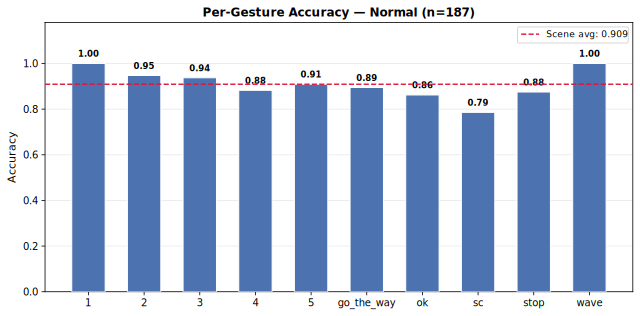

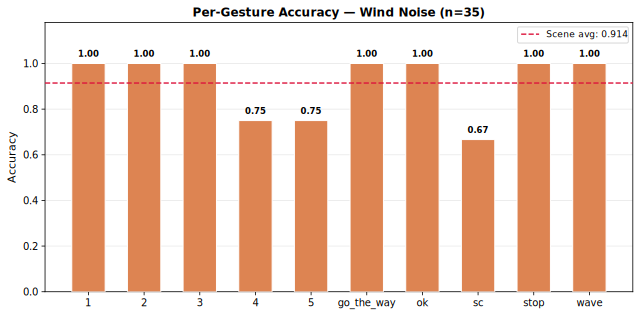

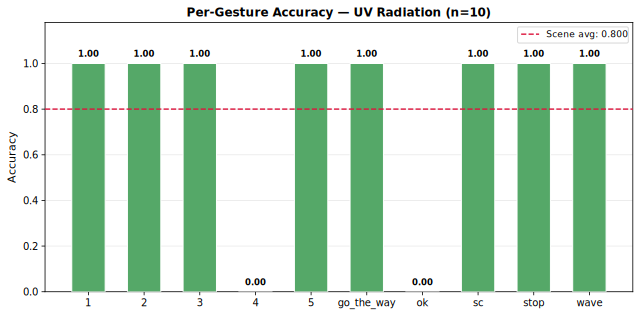

In [2]:
for env in ENVS:
    mask=envs_te==env; y_env=y_te[mask]; p_env=pred_all[mask]; n_env=mask.sum()
    per_cls=[accuracy_score(y_env[y_env==meta[meta['gesture_name']==g]['label'].iloc[0]],
                            p_env[y_env==meta[meta['gesture_name']==g]['label'].iloc[0]])
             if (y_env==meta[meta['gesture_name']==g]['label'].iloc[0]).sum()>0 else float('nan')
             for g in GESTURE_NAMES]
    overall_env=accuracy_score(y_env,p_env)

    fig,ax=plt.subplots(figsize=(9,4.5))
    x=np.arange(len(GESTURE_NAMES))
    bars=ax.bar(x,per_cls,color=COLORS[env],edgecolor='white',width=0.6,zorder=3)
    ax.axhline(overall_env,color='crimson',linestyle='--',linewidth=1.4,
               label=f'Scene avg: {overall_env:.3f}',zorder=4)
    ax.set_xticks(x); ax.set_xticklabels(GESTURE_NAMES,fontsize=10)
    ax.set_ylim(0,1.18); ax.set_ylabel('Accuracy',fontsize=11)
    ax.set_title(f'Per-Gesture Accuracy — {ENV_LABELS[env]}  (n={n_env})',
                 fontsize=12,fontweight='bold')
    ax.legend(fontsize=9); ax.grid(axis='y',alpha=0.3,zorder=0)
    for bar,acc in zip(bars,per_cls):
        if not (acc!=acc):  # not nan
            ax.text(bar.get_x()+bar.get_width()/2,bar.get_height()+0.02,
                    f'{acc:.2f}',ha='center',va='bottom',fontsize=8.5,fontweight='bold')
    fig.tight_layout()
    p=SVG_DIR/f'per_gesture_acc_{env}.svg'
    fig.savefig(p,format='svg',bbox_inches='tight'); plt.close(fig)
    display(SVG(filename=str(p)))

## 2. Confusion Matrices by Scene

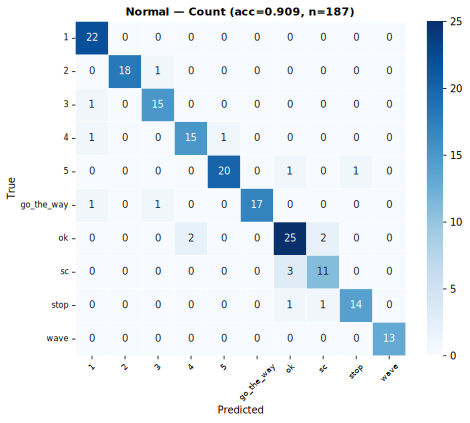

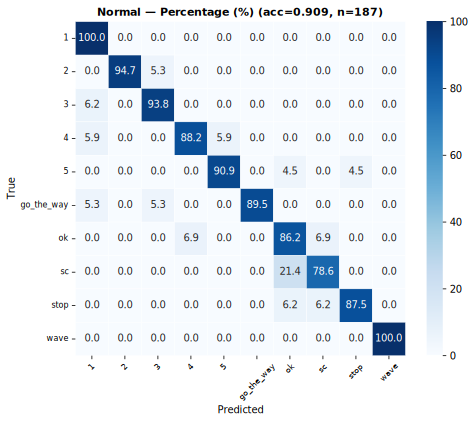

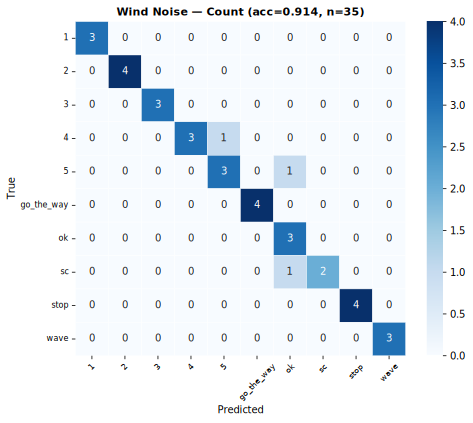

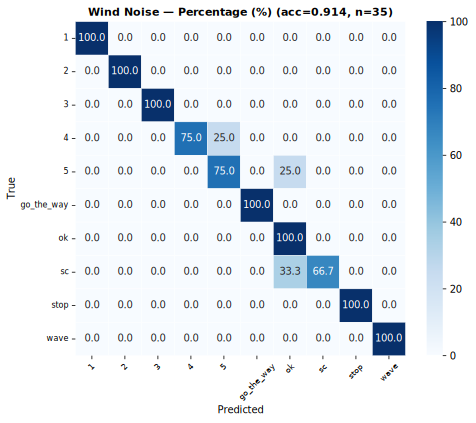

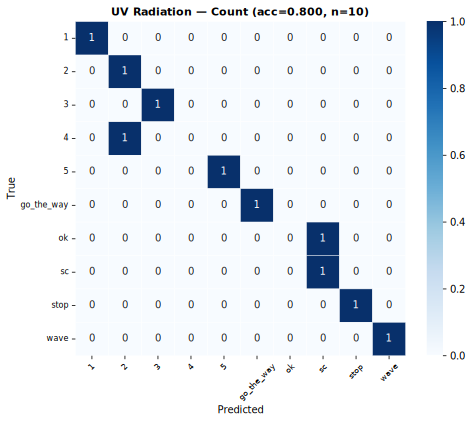

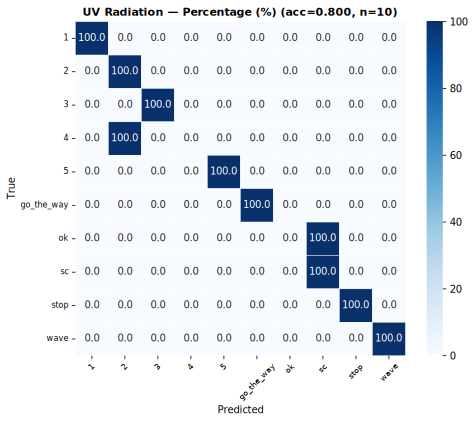

In [3]:
for env in ENVS:
    mask=envs_te==env; y_env=y_te[mask]; p_env=pred_all[mask]
    n_env=mask.sum(); acc_env=accuracy_score(y_env,p_env)
    cm_c=confusion_matrix(y_env,p_env,labels=label_order)
    cm_p=cm_c.astype(float)/cm_c.sum(axis=1,keepdims=True)*100

    for kind,(cm,fmt,vmax,label) in [
        ('count', (cm_c,'d',   None,  'Count')),
        ('pct',   (cm_p,'.1f', 100.0, 'Percentage (%)')),
    ]:
        fig,ax=plt.subplots(figsize=(7,6))
        sns.heatmap(cm,annot=True,fmt=fmt,cmap='Blues',
                    xticklabels=GESTURE_NAMES,yticklabels=GESTURE_NAMES,
                    vmin=0,vmax=vmax,linewidths=0.4,linecolor='white',ax=ax)
        ax.set_title(f'{ENV_LABELS[env]} — {label}  (acc={acc_env:.3f}, n={n_env})',
                     fontsize=11,fontweight='bold')
        ax.set_xlabel('Predicted'); ax.set_ylabel('True')
        ax.tick_params(axis='x',rotation=45,labelsize=8)
        ax.tick_params(axis='y',rotation=0, labelsize=8)
        fig.tight_layout()
        p=SVG_DIR/f'cm_{kind}_{env}.svg'
        fig.savefig(p,format='svg',bbox_inches='tight'); plt.close(fig)
        display(SVG(filename=str(p)))

## 3. Score Tables

Four tables — Accuracy, Recall, F1, Precision.
Rows: 10 gestures + Overall. Columns: Normal / Wind Noise / UV Radiation / Overall.

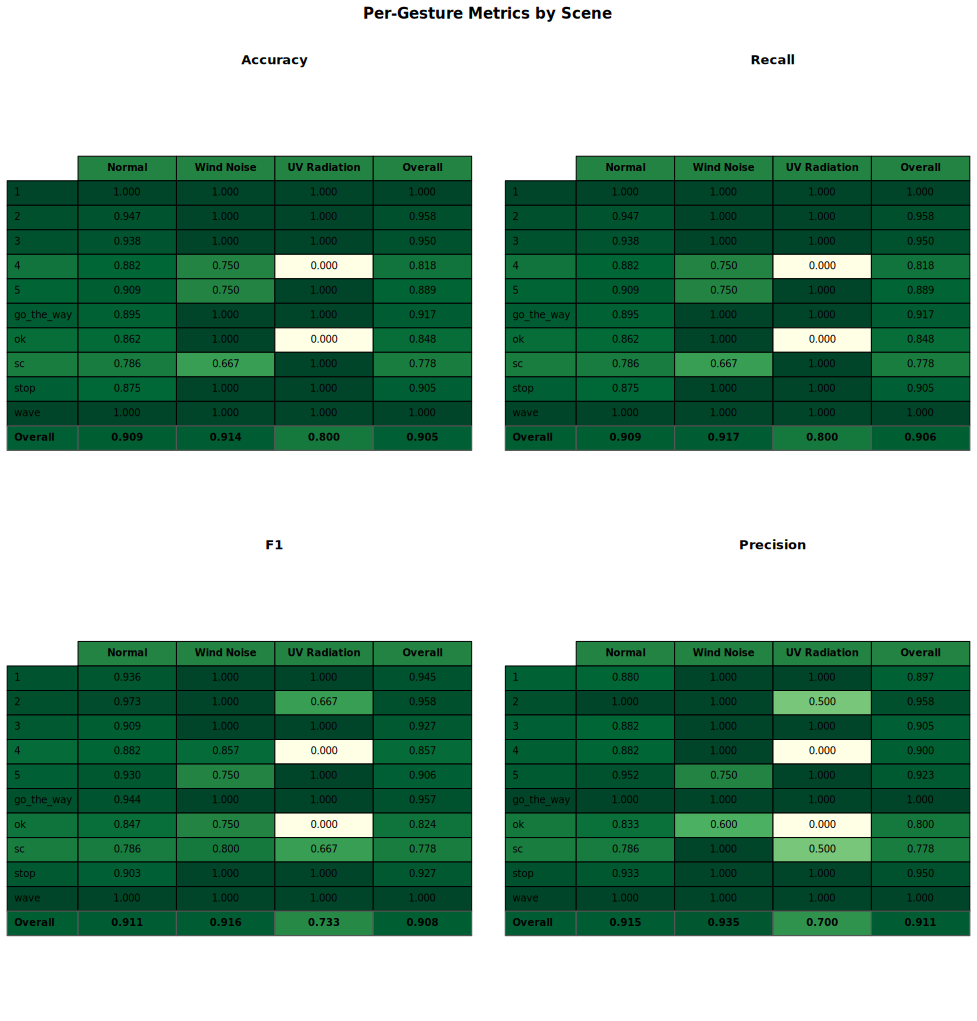

In [4]:
def compute_metrics(y_true, y_pred, label_order, gesture_names):
    """Returns dict of {metric: {gesture: value}} plus overall row."""
    results = {m: {} for m in ['Accuracy','Recall','F1','Precision']}
    for g, lbl in zip(gesture_names, label_order):
        m = y_true == lbl
        if m.sum() == 0:
            for met in results: results[met][g] = float('nan')
            continue
        yb = (y_true==lbl).astype(int); pb = (y_pred==lbl).astype(int)
        results['Accuracy'][g]  = accuracy_score(y_true[m], y_pred[m])
        results['Recall'][g]    = recall_score(yb, pb, zero_division=0)
        results['F1'][g]        = f1_score(yb, pb, zero_division=0)
        results['Precision'][g] = precision_score(yb, pb, zero_division=0)
    # Overall row
    results['Accuracy']['Overall']  = accuracy_score(y_true, y_pred)
    results['Recall']['Overall']    = recall_score(y_true, y_pred, average='macro', zero_division=0)
    results['F1']['Overall']        = f1_score(y_true, y_pred, average='macro', zero_division=0)
    results['Precision']['Overall'] = precision_score(y_true, y_pred, average='macro', zero_division=0)
    return results

# compute per env + overall
env_metrics = {}
for env in ENVS:
    mask = envs_te == env
    env_metrics[env] = compute_metrics(y_te[mask], pred_all[mask], label_order, GESTURE_NAMES)
env_metrics['overall'] = compute_metrics(y_te, pred_all, label_order, GESTURE_NAMES)

col_keys   = ENVS + ['overall']
col_labels = [ENV_LABELS[e] for e in ENVS] + ['Overall']
row_keys   = GESTURE_NAMES + ['Overall']

def make_table(metric):
    data = {}
    for ck, cl in zip(col_keys, col_labels):
        col = [env_metrics[ck][metric].get(r, float('nan')) for r in row_keys]
        data[cl] = col
    return pd.DataFrame(data, index=row_keys)

def plot_table(metric, ax, cmap='YlGn'):
    df = make_table(metric)
    vals = df.values.astype(float)
    # color map: nan -> light gray
    import matplotlib.colors as mcolors
    norm = mcolors.Normalize(vmin=0, vmax=1)
    cm   = plt.get_cmap(cmap)
    cell_colors = []
    for row in vals:
        cell_colors.append([
            (0.92, 0.92, 0.92, 1.0) if (v != v) else cm(norm(v))
            for v in row
        ])
    ax.axis('off')
    tbl = ax.table(
        cellText=[[f'{v:.3f}' if v==v else 'N/A' for v in row] for row in vals],
        rowLabels=row_keys,
        colLabels=col_labels,
        cellColours=cell_colors,
        rowColours=[cm(norm(vals[i, -1])) if vals[i,-1]==vals[i,-1] else (0.92,0.92,0.92,1) for i in range(len(row_keys))],
        colColours=[cm(norm(0.75))]*len(col_labels),
        loc='center', cellLoc='center'
    )
    tbl.auto_set_font_size(False); tbl.set_fontsize(10)
    tbl.scale(1.35, 1.6)
    # bold Overall row and column
    for (r,c), cell in tbl.get_celld().items():
        is_overall_row = (r == len(row_keys))
        is_overall_col = (c == len(col_labels))
        if is_overall_row or is_overall_col or r==0:
            cell.set_text_props(fontweight='bold')
        if is_overall_row and r > 0:
            cell.set_edgecolor('#555'); cell.set_linewidth(1.2)
    ax.set_title(metric, fontsize=13, fontweight='bold', pad=14)

fig, axes = plt.subplots(2, 2, figsize=(14, 14))
for ax, metric in zip(axes.flat, ['Accuracy','Recall','F1','Precision']):
    plot_table(metric, ax)
fig.suptitle('Per-Gesture Metrics by Scene', fontsize=15, fontweight='bold', y=1.01)
fig.tight_layout()
p = SVG_DIR / 'score_tables.svg'
fig.savefig(p, format='svg', bbox_inches='tight')
plt.close(fig)
display(SVG(filename=str(p)))